## מרשימה למערך: וקטוריזציה

רשימה בפייתון היא מבנה נתונים כללי: פעולות חשבון עליה אינן מוגדרות איבר-איבר. הביטוי `[1, 2, 3] + [4, 5, 6]` אינו מבצע חיבור איברים, אלא שרשור (concatenation) של שתי הרשימות. כדי לבצע חישוב על כל איברי הרשימה יש לרוץ עליה בלולאה, כפי שנעשה בשבוע 3.

NumPy מגדיר טיפוס נתונים חדש — **מערך (array)** — שכל איבריו מאותו טיפוס, ופעולות חשבון עליו מתבצעות על כלל האיברים בבת אחת. תהליך זה נקרא **וקטוריזציה**, והוא לא רק תמציתי יותר לכתיבה אלא גם מהיר משמעותית, מכיוון שהלולאה מתבצעת ברמת קוד C ולא בפייתון עצמה.

### דוגמה: גובה של זריקה

כדור נזרק כלפי מעלה במהירות התחלתית $v_0 = 15\ \text{m/s}$ מגובה $y_0 = 0$. הגובה בזמן $t$ נתון על ידי:

$$y(t) = y_0 + v_0 t - \tfrac{1}{2} g t^2$$

נחשב את הגובה בעשר נקודות זמן בין $t=0$ ל-$t=3$ שניות, בשתי דרכים.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8
y0, v0 = 0.0, 15.0
t_list = [0.0, 0.333, 0.667, 1.0, 1.333, 1.667, 2.0, 2.333, 2.667, 3.0]  # כמו בשבוע 3

# דרך 1: לולאה (שבוע 3)
y_loop = []
for t in t_list:
    y_loop.append(y0 + v0 * t - 0.5 * g * t**2)
print(y_loop)

[0.0, 4.4516439, 7.825043900000001, 10.1, 11.288243900000001, 11.388443899999999, 10.399999999999999, 8.324843899999998, 5.151843899999996, 0.8999999999999986]


עכשיו אותו חישוב עם מערך NumPy — ללא לולאה מפורשת:

In [2]:
t_arr = np.array(t_list)

# דרך 2: וקטוריזציה
y_arr = y0 + v0 * t_arr - 0.5 * g * t_arr**2
print(y_arr)

[ 0.         4.4516439  7.8250439 10.1       11.2882439 11.3884439
 10.4        8.3248439  5.1518439  0.9      ]


שתי הדרכים מניבות אותה תוצאה, אך הביטוי הווקטורי קצר יותר, קריא יותר (כמעט זהה לנוסחה $y(t)$ עצמה), ומהיר משמעותית כאשר מספר הנקודות גדול — למשל אלף מדידות מניסוי, לא עשר.

```{note}
`t_list + 1` על רשימה רגילה גורם לשגיאה (אי אפשר לחבר רשימה למספר). `t_arr + 1` על מערך NumPy מוסיף 1 לכל איבר. זהו ההבדל המהותי בין השניים.
```

נצייר את מסלול הזריקה כדי לראות שהתוצאה היא אכן פרבולה, כצפוי פיזיקלית:

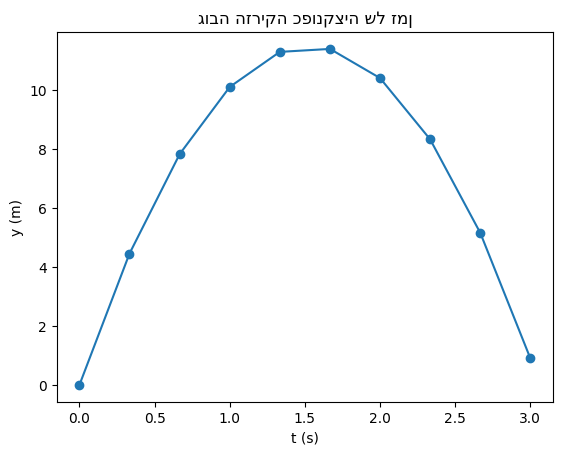

In [3]:
fig, ax = plt.subplots()
ax.plot(t_arr, y_arr, marker="o")
ax.set_xlabel("t (s)")
ax.set_ylabel("y (m)")
ax.set_title("גובה הזריקה כפונקציה של זמן")
plt.show()

### נסו בעצמכם

המהירות האנכית של הכדור נתונה על ידי $v(t) = v_0 - g t$. השלימו את החישוב הווקטורי (ללא לולאה):

In [4]:
# v_arr = ...
# print(v_arr)

`````{admonition} פתרון
:class: dropdown, tip
```python
v_arr = v0 - g * t_arr
print(v_arr)
```
`````

### בדקו את עצמכם

In [5]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "בהינתן <code>a = [1, 2, 3]</code> (רשימה רגילה) ו-<code>b = np.array([1, 2, 3])</code> (מערך NumPy), מה התוצאה של <code>a * 2</code> לעומת <code>b * 2</code>?",
        "type": "multiple_choice",
        "answers": [
            {
                "answer": "a*2 נותן [2, 4, 6], וגם b*2 נותן [2, 4, 6]",
                "correct": False,
                "feedback": "לא מדויק — a*2 על רשימה אינו מכפיל כל איבר. נסו להריץ בעצמכם."
            },
            {
                "answer": "a*2 נותן [1, 2, 3, 1, 2, 3] (הרשימה חוזרת פעמיים), ו-b*2 נותן [2, 4, 6]",
                "correct": True,
                "feedback": "נכון. על רשימה, האופרטור * חוזר על האיברים; על מערך NumPy, הוא מכפיל כל איבר בנפרד."
            },
            {
                "answer": "שתי הפעולות גורמות לשגיאה",
                "correct": False,
                "feedback": "לא — שתי הפעולות חוקיות, אך עושות דברים שונים לחלוטין."
            }
        ]
    }
]

display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

כדור נופל בנפילה חופשית מגובה $h_0 = 20\ \text{m}$, ללא מהירות התחלתית. המהירות שלו בזמן $t$ נתונה על ידי $v(t) = -g t$.

נתון וקטור הזמנים הבא:

In [6]:
t_free = np.array([0.0, 0.5, 1.0, 1.5, 2.0])

# חשבו את v(t) עבור כל זמן ב-t_free, ללא לולאה
# v_free = ...
# print(v_free)

`````{admonition} פתרון
:class: dropdown, tip
```python
v_free = -g * t_free
print(v_free)
```
`````